# Quantum data example in Kappen (2018)
This notebook reproduces the example in Section 4 of [Kappen](https://arxiv.org/abs/1803.11278)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates

In [4]:
# define number of sites == number of qubits (each site is a 2-level system)
n = 6 ## change this to 10 to reproduce the paper results

6

## Target state

The quantum state we set up to learn using a QBM is a thermal state (for three different temperatures) from the Hamiltonian of the 1D Heisenberg model with nearest-neighbors interactions, isotropic couplings and zero single-site fields. We report here the full Eq. (13) of the [paper](https://arxiv.org/abs/1803.11278):
\begin{equation}
H = \sum_{i=1}^{n} \sum_{k = x, y, z} w_i^{k} \sigma_i^{k}
    + \sum_{i=1}^{n} \sum_{j > i}^{n} \sum_{k = x, y, z} w_{ij}^{k} \sigma_i^{k} \sigma_j^{k},
\end{equation}
where $\sigma_j^{k}$ are Pauli operators on site $j$ and $n$ is the total number of sites.

The target state is generated with the Hamiltonian where
$$
w_{ij}^{x,y,z} = 1 \text{ for nearest neighbors,} \quad 
w_{ij}^{x,y,z} = 0 \text{ otherwise, and } w_i^{k} = 0.
$$


### Hamiltonian 
For this example, we work under the (simplifying) assumption that each spin direction will have a separate parameter, but that the interaction in a fixed spin direction is isotropic along the spin chain of 
sites (we also include periodic boundary conditions). This amounts to the Hamiltonian of the `XYZ` Heisenberg model, but when the `x`, `y`, and `z` couplings are the same, then it is the `XXX` Heisenberg model:

In [5]:
# Fix the parameters of the hamiltonian:
# - 3 parameters for the nearest-neighbors terms
target_interactions = (1.0, 1.0, 1.0)
@printf("Spin interaction used to create target state: %s\n", target_interactions)

Spin interaction used to create target state: (1.0, 1.0, 1.0)


In [6]:
target_interactions = 4 .* target_interactions
params_target = parameters(:heisenberg, n; coupling_vals=Dict(:XX => target_interactions[1], :YY => target_interactions[2], :ZZ => target_interactions[3]))

target_xxx = makehamiltonian(params_target; connectivity=:nearest, periodic=true)

18-element Vector{PauliString}:
 PauliString(nqubits: 6, 1.0 * XXIIII)
 PauliString(nqubits: 6, 1.0 * YYIIII)
 PauliString(nqubits: 6, 1.0 * ZZIIII)
 PauliString(nqubits: 6, 1.0 * IXXIII)
 PauliString(nqubits: 6, 1.0 * IYYIII)
 PauliString(nqubits: 6, 1.0 * IZZIII)
 PauliString(nqubits: 6, 1.0 * IIXXII)
 PauliString(nqubits: 6, 1.0 * IIYYII)
 PauliString(nqubits: 6, 1.0 * IIZZII)
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 1.0 * IIIZZI)
 PauliString(nqubits: 6, 1.0 * IIIIXX)
 PauliString(nqubits: 6, 1.0 * IIIIYY)
 PauliString(nqubits: 6, 1.0 * IIIIZZ)
 PauliString(nqubits: 6, 1.0 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 1.0 * ZIIIIZ)

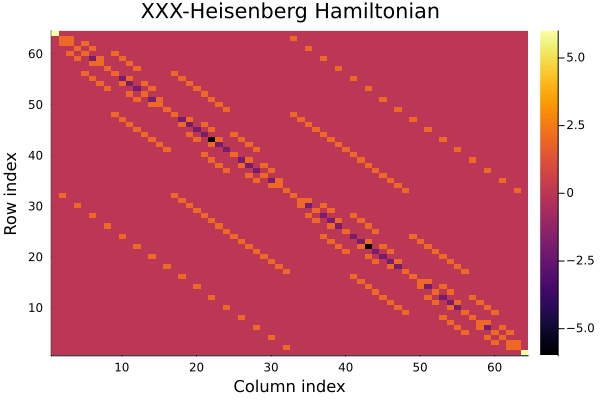

In [7]:
target_xxx_matrix = paulistringtomatrix(target_xxx)

heatmap(reverse(real(target_xxx_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XXX-Heisenberg Hamiltonian"
        )

### Density matrix

The paper generates a density matrix from the `XXX ` Hamiltonian at 3 different temperatures $T = 1/\beta$
, with $\beta =1,2,∞$

In [8]:
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20;

In [9]:
target_beta01 = .1

target_xxx_beta01 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta01
target_xxx_matrix_beta01 = paulistringtomatrix(target_xxx_beta01)
targert_circuit_beta01, θ_beta01 = paulistringtocircuit(target_xxx_beta01)

target_eta_beta01 = makethermalstate(n, targert_circuit_beta01, θ_beta01, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta01_matrix = paulistringtomatrix(target_eta_beta01);

In [10]:
target_beta1 = 1

target_xxx_beta1 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta1
target_xxx_matrix_beta1 = paulistringtomatrix(target_xxx_beta1)
targert_circuit_beta1, θ_beta1 = paulistringtocircuit(target_xxx_beta1)

target_eta_beta1 = makethermalstate(n, targert_circuit_beta1, θ_beta1, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1);

In [11]:
target_beta2 = 2

target_xxx_beta2 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta2
target_xxx_matrix_beta2 = paulistringtomatrix(target_xxx_beta2)
targert_circuit_beta2, θ_beta2 = paulistringtocircuit(target_xxx_beta2)

target_eta_beta2 = makethermalstate(n, targert_circuit_beta2, θ_beta2, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta2_matrix = paulistringtomatrix(target_eta_beta2);

In [12]:
target_beta∞ = 60

target_xxx_beta∞ = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta∞
target_xxx_matrix_beta∞ = paulistringtomatrix(target_xxx_beta∞)
targert_circuit_beta∞, θ_beta∞ = paulistringtocircuit(target_xxx_beta∞)

target_eta_beta∞ = makethermalstate(n, targert_circuit_beta∞, θ_beta∞, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta∞_matrix = paulistringtomatrix(target_eta_beta∞);

## Quantum Boltzmann Machine model

Following the paper we now define the QBM based on the same `XYZ` Heisenberg Hamiltonian used to define the target state. We let the 3 parameters for each spin direction to have arbitrary values.

In [13]:
# parameters to learn. Set initial values at random
rng = MersenneTwister()  
interactions = Tuple(randn(rng, 3))        
fields       = Tuple(randn(rng, 3))
@printf("Spin interaction: %s\n", interactions)
@printf("Field value: %s\n", fields)

Spin interaction: (-0.07407179111724894, 0.13177142198153066, -0.6622768725621766)
Field value: (-1.1891745905748103, -1.046689624381662, -0.1264372575962375)


In [14]:
params = parameters(:heisenberg_fields, n; field_vals=Dict(:X => fields[1], :Y => fields[2], :Z => fields[3]), coupling_vals=Dict(:XX => interactions[1], :YY => interactions[2], :ZZ => interactions[3]))

beta_qbm = 1
qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta_qbm

36-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.59459 * XIIIII)
 PauliString(nqubits: 6, -0.52334 * YIIIII)
 PauliString(nqubits: 6, -0.063219 * ZIIIII)
 PauliString(nqubits: 6, -0.59459 * IXIIII)
 PauliString(nqubits: 6, -0.52334 * IYIIII)
 PauliString(nqubits: 6, -0.063219 * IZIIII)
 PauliString(nqubits: 6, -0.59459 * IIXIII)
 PauliString(nqubits: 6, -0.52334 * IIYIII)
 PauliString(nqubits: 6, -0.063219 * IIZIII)
 PauliString(nqubits: 6, -0.59459 * IIIXII)
 ⋮
 PauliString(nqubits: 6, -0.018518 * IIIXXI)
 PauliString(nqubits: 6, 0.032943 * IIIYYI)
 PauliString(nqubits: 6, -0.16557 * IIIZZI)
 PauliString(nqubits: 6, -0.018518 * IIIIXX)
 PauliString(nqubits: 6, 0.032943 * IIIIYY)
 PauliString(nqubits: 6, -0.16557 * IIIIZZ)
 PauliString(nqubits: 6, -0.018518 * XIIIIX)
 PauliString(nqubits: 6, 0.032943 * YIIIIY)
 PauliString(nqubits: 6, -0.16557 * ZIIIIZ)

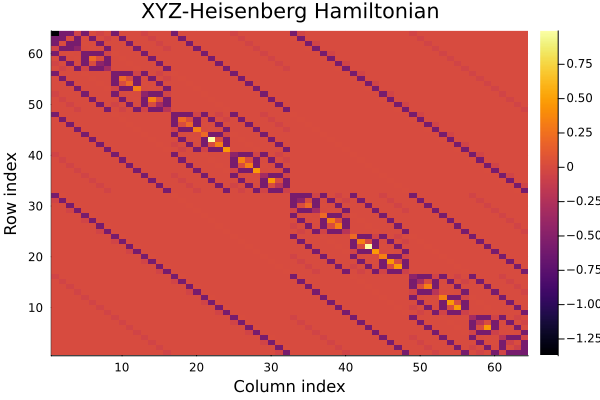

In [15]:
qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)

heatmap(reverse(real(qbm_xyz_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XYZ-Heisenberg Hamiltonian"
        )

### Gibbs state
The corresponding Gibbs state for this initial Hamiltonian is
$$\rho_\theta = \frac{e^{H_\theta}}{Z}$$

In [16]:
trial_circuit, trial_θ = paulistringtocircuit(qbm_xyz)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20

rho_qbm = makethermalstate(n, trial_circuit, trial_θ, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

rho_qbm_matrix = paulistringtomatrix(rho_qbm);

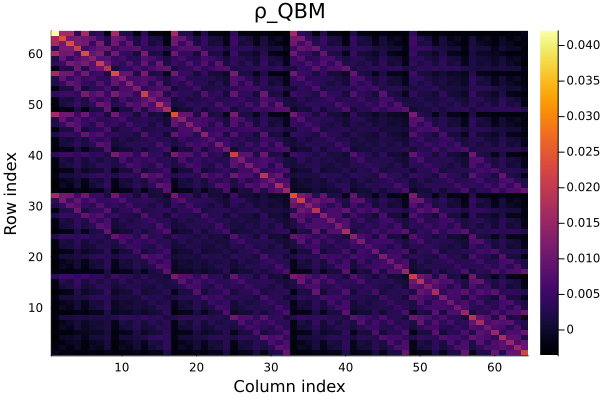

In [17]:
heatmap(reverse(real(rho_qbm_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="ρ_QBM"
        )

## Training of the QBM


In [18]:
target_probs_beta01 = computesymmetriceigenvalues(target_eta_beta01_matrix)
target_probs_beta01 = clamp.(target_probs_beta01, 1e-300, Inf);

target_probs_beta1 = computesymmetriceigenvalues(target_eta_beta1_matrix)
target_probs_beta1 = clamp.(target_probs_beta1, 1e-300, Inf);

target_probs_beta2 = computesymmetriceigenvalues(target_eta_beta2_matrix)
target_probs_beta2 = clamp.(target_probs_beta2, 1e-300, Inf);

target_probs_beta∞ = computesymmetriceigenvalues(target_eta_beta∞_matrix)
target_probs_beta∞ = clamp.(target_probs_beta∞ , 1e-300, Inf);

In [19]:
# --- Initialization ---
beta = 1
qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1,     qbm_xyz_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    max_weight = n
    min_abs_coeff = 1e-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    max_weight=max_weight, min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_xyz, target_eta_beta1, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_xyz, grads, gamma)

    # --- Diagnostics ---
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.002098
  Max abs gradient:         0.004373

Epoch 200
  Quantum relative entropy: 0.000175
  Max abs gradient:         0.000575

Epoch 300
  Quantum relative entropy: 0.000134
  Max abs gradient:         0.000091

Epoch 400
  Quantum relative entropy: 0.000134
  Max abs gradient:         0.000019

Epoch 500
  Quantum relative entropy: 0.000134
  Max abs gradient:         0.000004

Epoch 600
  Quantum relative entropy: 0.000134
  Max abs gradient:         0.000001
Converged: max gradient < epsilon


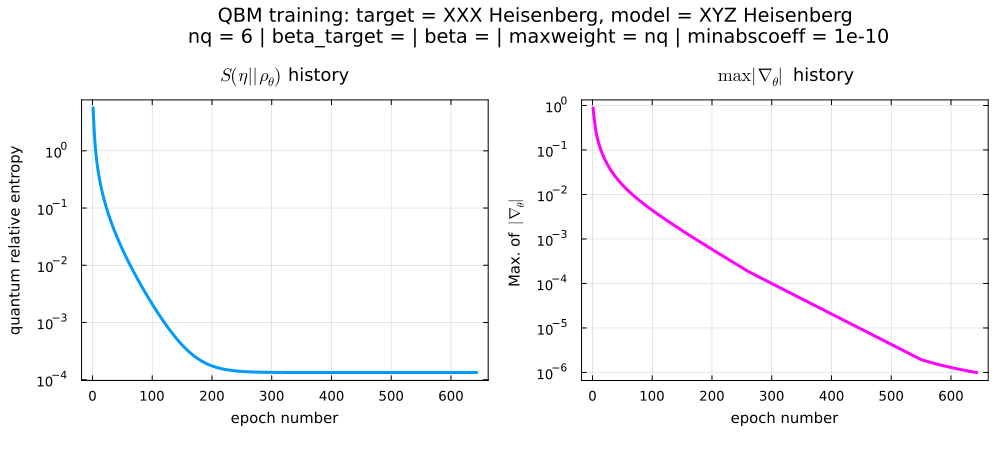

In [25]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX Heisenberg, model = XYZ Heisenberg\n nq = 6 | beta_target = 1 | beta = 1 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [28]:
@printf("Original target hamiltonian:")
target_xxx_beta1

Original target hamiltonian:

18-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, 1.0 * XXIIII)
 PauliString(nqubits: 6, 1.0 * YYIIII)
 PauliString(nqubits: 6, 1.0 * ZZIIII)
 PauliString(nqubits: 6, 1.0 * IXXIII)
 PauliString(nqubits: 6, 1.0 * IYYIII)
 PauliString(nqubits: 6, 1.0 * IZZIII)
 PauliString(nqubits: 6, 1.0 * IIXXII)
 PauliString(nqubits: 6, 1.0 * IIYYII)
 PauliString(nqubits: 6, 1.0 * IIZZII)
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 1.0 * IIIZZI)
 PauliString(nqubits: 6, 1.0 * IIIIXX)
 PauliString(nqubits: 6, 1.0 * IIIIYY)
 PauliString(nqubits: 6, 1.0 * IIIIZZ)
 PauliString(nqubits: 6, 1.0 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 1.0 * ZIIIIZ)

In [29]:
@printf("Learnt hamiltonian:")
qbm_xyz

Learnt hamiltonian:

36-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -3.6809e-7 * XIIIII)
 PauliString(nqubits: 6, -3.2495e-6 * YIIIII)
 PauliString(nqubits: 6, 5.6353e-6 * ZIIIII)
 PauliString(nqubits: 6, -3.72e-7 * IXIIII)
 PauliString(nqubits: 6, -3.2844e-6 * IYIIII)
 PauliString(nqubits: 6, 5.6961e-6 * IZIIII)
 PauliString(nqubits: 6, -3.7016e-7 * IIXIII)
 PauliString(nqubits: 6, -3.2669e-6 * IIYIII)
 PauliString(nqubits: 6, 5.6654e-6 * IIZIII)
 PauliString(nqubits: 6, -3.6844e-7 * IIIXII)
 ⋮
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 0.99995 * IIIZZI)
 PauliString(nqubits: 6, 0.99995 * IIIIXX)
 PauliString(nqubits: 6, 0.99999 * IIIIYY)
 PauliString(nqubits: 6, 1.0001 * IIIIZZ)
 PauliString(nqubits: 6, 1.0001 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 0.99994 * ZIIIIZ)

In [51]:
# --- Initialization ---
beta = 1
qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 500
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1,     qbm_xyz_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    max_weight = n
    min_abs_coeff = 2^-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    max_weight=max_weight, min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_xyz, target_eta_beta1, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_xyz, grads, gamma)

    # --- Diagnostics ---
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.382953
  Max abs gradient:         0.002011

Epoch 200
  Quantum relative entropy: 0.383334
  Max abs gradient:         0.001847

Epoch 300
  Quantum relative entropy: 0.382182
  Max abs gradient:         0.001471

Epoch 400
  Quantum relative entropy: 0.381909
  Max abs gradient:         0.000005

Epoch 500
  Quantum relative entropy: 0.381904
  Max abs gradient:         0.000001


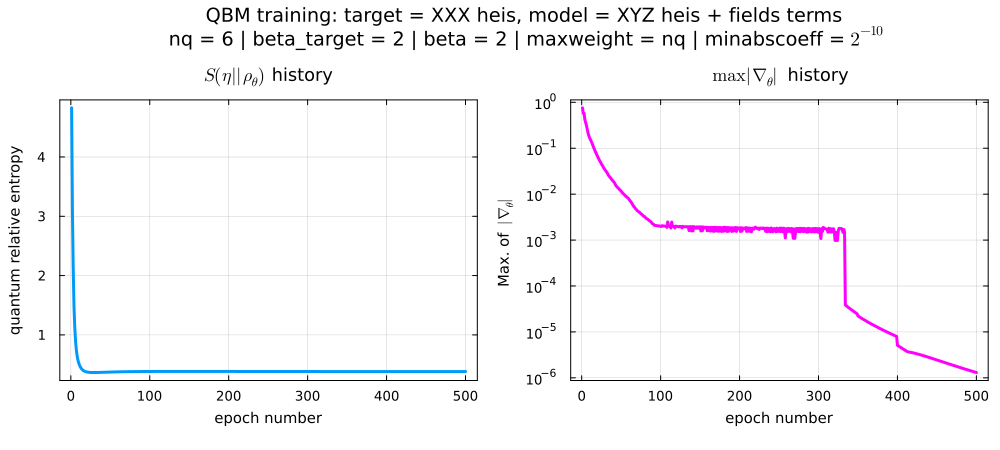

In [55]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX heis, model = XYZ heis + fields terms\n nq = 6 | beta_target = 2 | beta = 2 | maxweight = nq | minabscoeff = " * L"2^{-10}",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [53]:
@printf("Learnt hamiltonian:")
qbm_xyz

Learnt hamiltonian:

36-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.097563 * XIIIII)
 PauliString(nqubits: 6, 0.097638 * YIIIII)
 PauliString(nqubits: 6, 0.097589 * ZIIIII)
 PauliString(nqubits: 6, -0.10357 * IXIIII)
 PauliString(nqubits: 6, 0.10167 * IYIIII)
 PauliString(nqubits: 6, 0.10332 * IZIIII)
 PauliString(nqubits: 6, -0.11107 * IIXIII)
 PauliString(nqubits: 6, 0.1026 * IIYIII)
 PauliString(nqubits: 6, 0.11098 * IIZIII)
 PauliString(nqubits: 6, -0.11032 * IIIXII)
 ⋮
 PauliString(nqubits: 6, 1.0011 * IIIXXI)
 PauliString(nqubits: 6, 1.0009 * IIIYYI)
 PauliString(nqubits: 6, 1.0012 * IIIZZI)
 PauliString(nqubits: 6, 1.001 * IIIIXX)
 PauliString(nqubits: 6, 1.0007 * IIIIYY)
 PauliString(nqubits: 6, 1.0008 * IIIIZZ)
 PauliString(nqubits: 6, 1.0006 * XIIIIX)
 PauliString(nqubits: 6, 1.0007 * YIIIIY)
 PauliString(nqubits: 6, 1.0005 * ZIIIIZ)

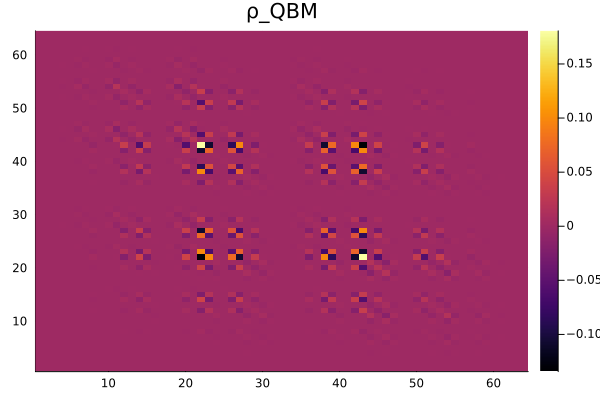

In [37]:
beta = 1.
qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, theta = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
max_weight = n
min_abs_coeff = 1e-10
qbm = makethermalstate(n, circuit, theta, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

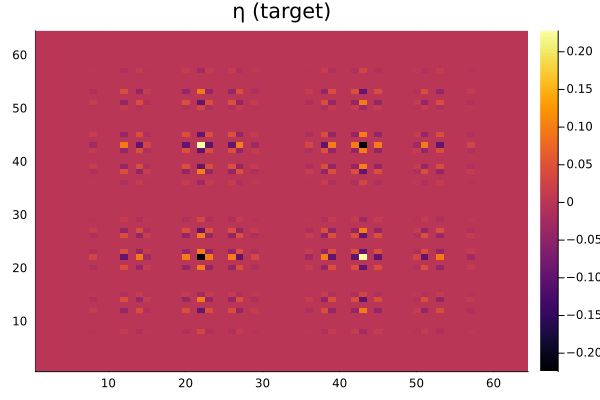

In [38]:
heatmap(reverse(real(target_eta_beta2_matrix); dims=1), title="η (target)")

### Different temperatures


Starting optimization for β = 0.050
  [β=0.05 | epoch= 100]  QRE = 3.704150e-01   max|∇| = 1.870347e-03
  [β=0.05 | epoch= 200]  QRE = 3.739203e-01   max|∇| = 1.044579e-04
  [β=0.05 | epoch= 300]  QRE = 3.741008e-01   max|∇| = 6.767139e-06
Converged: max gradient < epsilon

Finished β = 0.050  → epochs: 391 | final QRE = 3.741142e-01 | final max|∇| = 9.872e-07
------------------------------------------------------------
  → Saved CSV data to /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/targetXXX_qbmXYZ+fields_6qb_trunccoeff2^-10_beta0.05.csv
  → Saved metadata to /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/targetXXX_qbmXYZ+fields_6qb_trunccoeff2^-10_beta0.05_metadata.json

Starting optimization for β = 0.500
  [β=0.50 | epoch= 100]  QRE = 3.766852e-01   max|∇| = 1.844200e-03
  [β=0.50 | epoch= 200]  QRE = 3.800352e-01   max|∇| = 1.036189e-04
  [β=0.50 | epoch= 300]  QRE = 3.802031e-01   max|∇| = 6.4

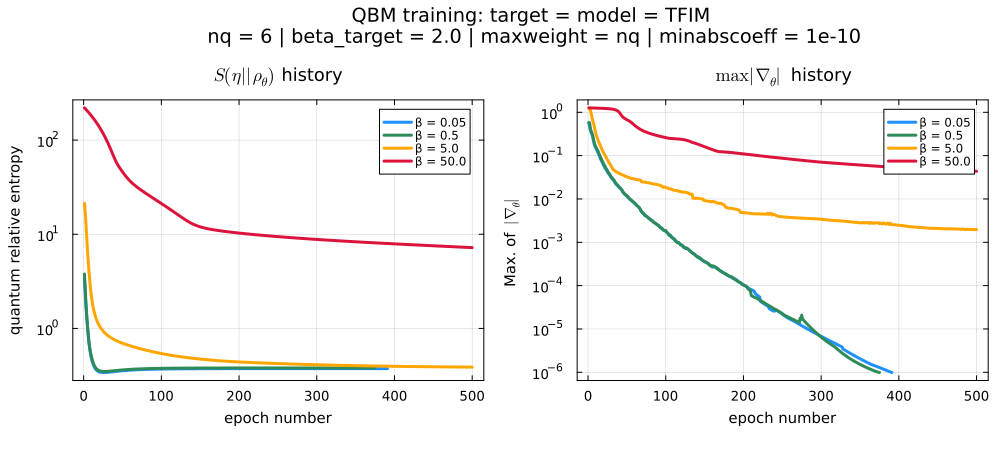

In [33]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

n = 6 

# target
## target hamiltonian
target_beta = 1
target_interactions = (1.0, 1.0, 1.0)
target_interactions = 4 .* target_interactions
params_target = parameters(:heisenberg, n; coupling_vals=Dict(:XX => target_interactions[1], :YY => target_interactions[2], :ZZ => target_interactions[3])) 
target_xxx_beta1 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta
target_xxx_matrix_beta1 = paulistringtomatrix(target_xxx_beta1)
## target state
num_layers_target = 100
max_weight_target = n
min_abs_coeff_target = 1e-20
targert_circuit_beta1, θ_beta1 = paulistringtocircuit(target_xxx_beta1)
target_eta_beta1 = makethermalstate(n, targert_circuit_beta1, θ_beta1, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)
target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1)

# QBM model
rng = MersenneTwister()  
interactions = Tuple(randn(rng, 3))        
fields       = Tuple(randn(rng, 3))
params = parameters(:heisenberg_fields, n; field_vals=Dict(:X => fields[1], :Y => fields[2], :Z => fields[3]), coupling_vals=Dict(:XX => interactions[1], :YY => interactions[2], :ZZ => interactions[3]))

# beta values 
beta_values = [0.05, 0.5, 5, 50]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 500
# stop when gradient is smaller than epsilon
epsilon = 1e-6

# Output path
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetXXX_qbmXYZ+fields_6qb_trunccoeff2^-10"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over β values
for (i, beta) in enumerate(beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for β = %.3f\n", beta)
    println("="^60)

    # QBM model
    qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta
    ## truncation parameters
    num_layers_qbm = 100
    max_weight_qbm = n
    min_abs_coeff_qbm = 2^-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        # Build Hamiltonian matrix
        qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
        push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1,     qbm_xyz_matrix))

        # Create thermal state
        circuit, theta = paulistringtocircuit(qbm_xyz)
        rho = makethermalstate(n, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # --- Gradient computation (efficient) ---
        grads = computegradients(qbm_xyz, target_eta_beta1, rho)
        push!(grad_hist, abs.(grads))

        # --- Parameter update ---
        updatehamiltonian!(qbm_xyz, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [β=%.2f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this β
    @printf("\nFinished β = %.3f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # ------------------------- #
    # --- SAVE DATA TO FILE --- #
    # ------------------------- #

    # Save optimization histories as CSV
    df = DataFrame(epoch = 1:length(qre_hist),
                   qre = qre_hist,
                   max_grad = [maximum(g) for g in grad_hist])
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    CSV.write(csv_path, df)
    @printf("  → Saved CSV data to %s\n", csv_path)

    # Collect metadata only once per run
    metadata = Dict(
        "timestamp" => string(now()),
        "model_target" => "TFIM",
        "model_qbm" => "TFIM",
        "n_qubits" => n,
        "beta_target" => target_beta,
        "beta_qbm" => beta,
        "beta_values" => beta_values,
        "learning_rate" => gamma,
        "epochs" => epochs,
        "epsilon" => epsilon,
        "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
                                "wij_xyz" => params_target.wij_xyz),
        "target_truncation" => Dict("max_weight" => max_weight_target,
                                    "min_abs_coeff" => min_abs_coeff_target,
                                    "num_layers" => num_layers_target),
        "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
                                 "min_abs_coeff" => min_abs_coeff_qbm,
                                 "num_layers" => num_layers_qbm)
    )

    json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    JSON3.write(json_path, metadata; indent=2)
    @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β = $(beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β = $(beta)", color = colors[i], lw = 3)
end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = model = TFIM\n nq = 6 | beta_target = 2.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

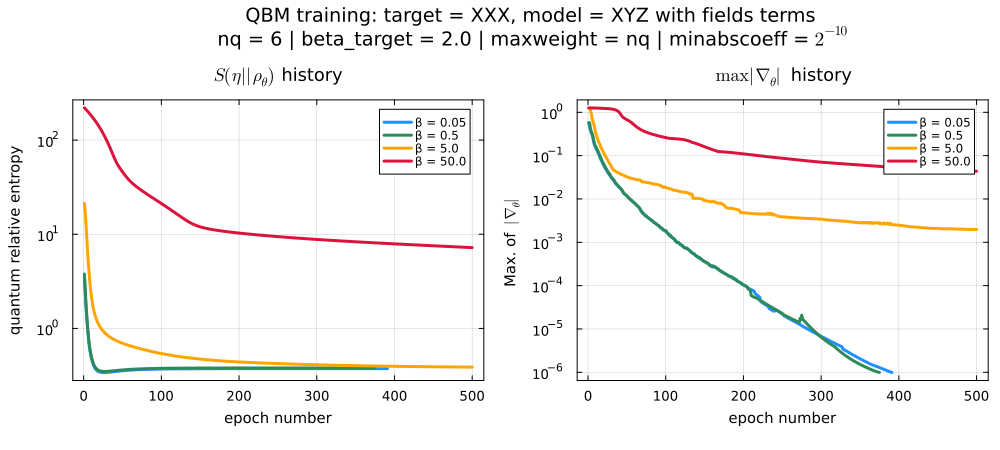

In [44]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX, model = XYZ with fields terms\n nq = 6 | beta_target = 2.0 | maxweight = nq | minabscoeff = " * L"2^{-10}",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)